In [22]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("hf://datasets/zefang-liu/phishing-email-dataset/Phishing_Email.csv")

df.head()


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

In [5]:
df.dropna(inplace=True)


In [6]:
df = df.rename(columns={
    'Email Text': 'email_text',
    'Email Type': 'label'
})

df['label'].value_counts()


label
Safe Email        11322
Phishing Email     7312
Name: count, dtype: int64

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text)
    return text


In [8]:
df['clean_email'] = df['email_text'].apply(clean_text)


In [9]:

df['label_binary'] = df['label'].map({
    'Phishing Email': 1,
    'Safe Email': 0
})


In [10]:
X = df['clean_email']
y = df['label_binary']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [12]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [13]:
y_pred = lr_model.predict(X_test_tfidf)
y_prob = lr_model.predict_proba(X_test_tfidf)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9643144620338073

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2265
           1       0.93      0.98      0.96      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.97      0.96      3727
weighted avg       0.97      0.96      0.96      3727



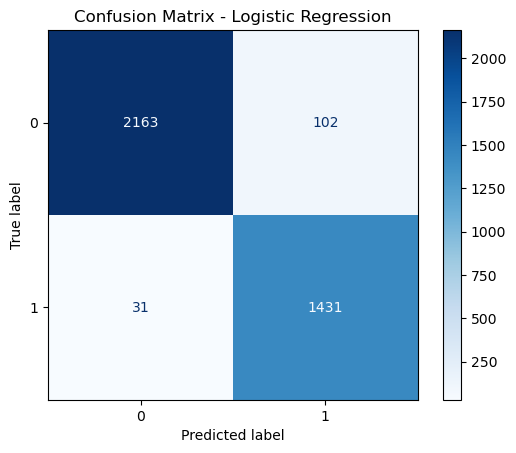

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


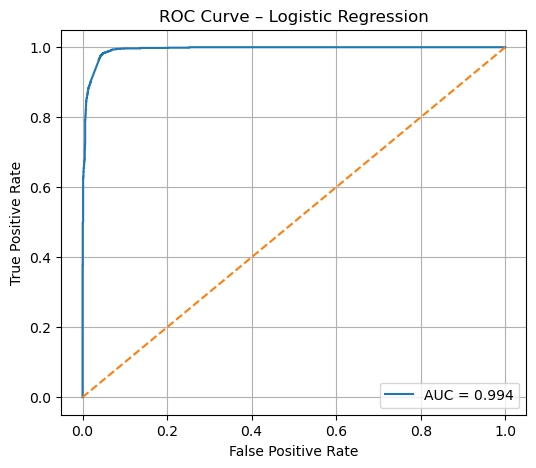

In [15]:
y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]

from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"AUC = {roc_auc_lr:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


In [19]:

y_pred_lr = lr_model.predict(X_test_tfidf)

y_train_pred_lr = lr_model.predict(X_train_tfidf)

print("Logistic Regression - TRAINING DATA\n")
print(classification_report(y_train, y_train_pred_lr))

print("\nLogistic Regression - TESTING DATA\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression - TRAINING DATA

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      9057
           1       0.95      0.99      0.97      5850

    accuracy                           0.98     14907
   macro avg       0.97      0.98      0.98     14907
weighted avg       0.98      0.98      0.98     14907


Logistic Regression - TESTING DATA

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2265
           1       0.93      0.98      0.96      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.97      0.96      3727
weighted avg       0.97      0.96      0.96      3727



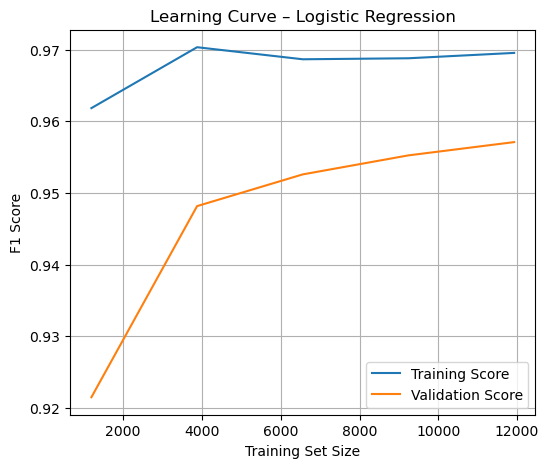

In [20]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(6,5))
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_learning_curve(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    X_train_tfidf,
    y_train,
    "Learning Curve – Logistic Regression"
)


In [26]:
!pip install wordcloud

In [27]:
from wordcloud import WordCloud
from collections import Counter

In [29]:
df['email_length'] = df['email_text'].apply(len)

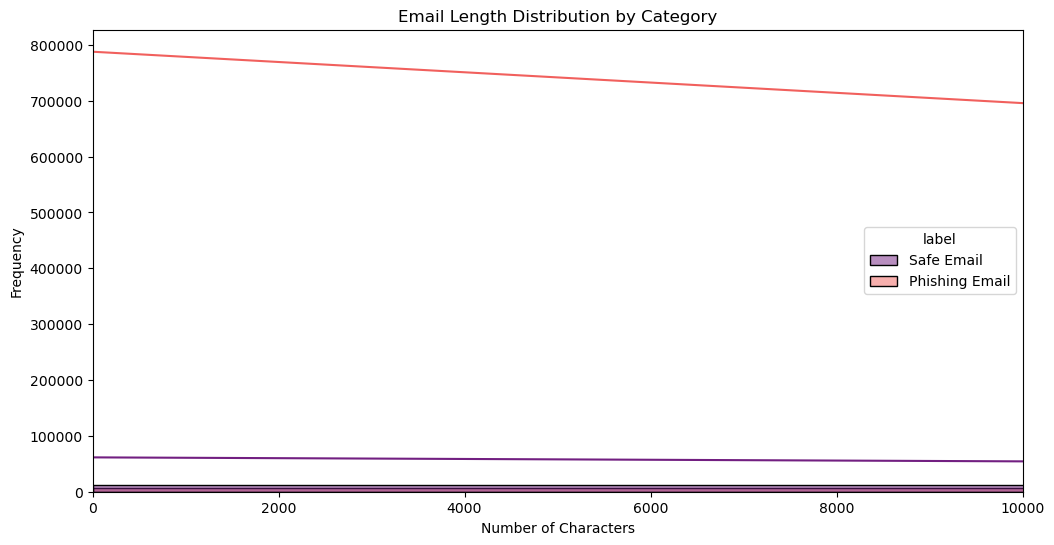

In [30]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='email_length', hue='label', bins=50, kde=True, palette='magma')
plt.title('Email Length Distribution by Category')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.xlim(0, 10000) 
plt.show()

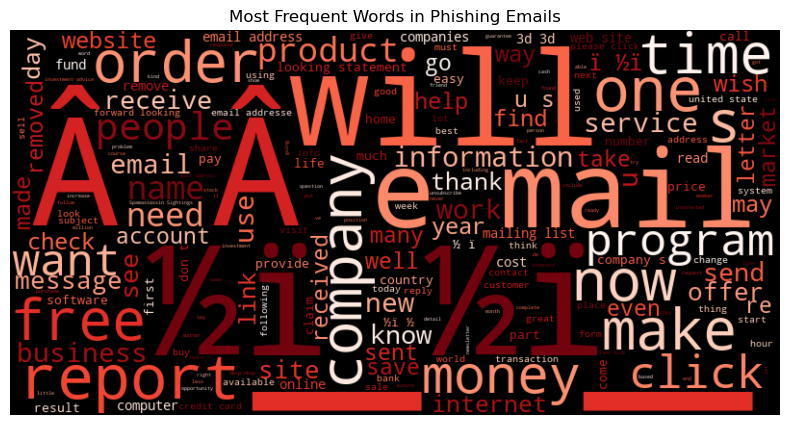

In [31]:
phishing_words = ' '.join(list(df[df['label_binary'] == 1]['email_text']))
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(phishing_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most Frequent Words in Phishing Emails')
plt.axis('off')
plt.show()

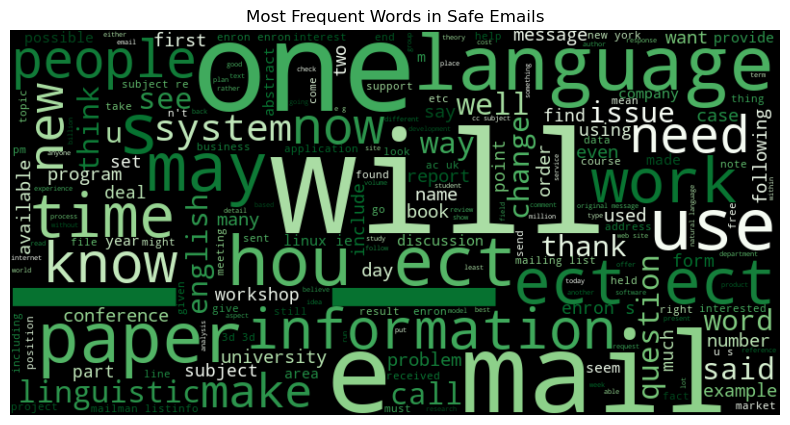

In [32]:
safe_words = ' '.join(list(df[df['label_binary'] == 0]['email_text']))
wordcloud_safe = WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(safe_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_safe, interpolation='bilinear')
plt.title('Most Frequent Words in Safe Emails')
plt.axis('off')
plt.show()

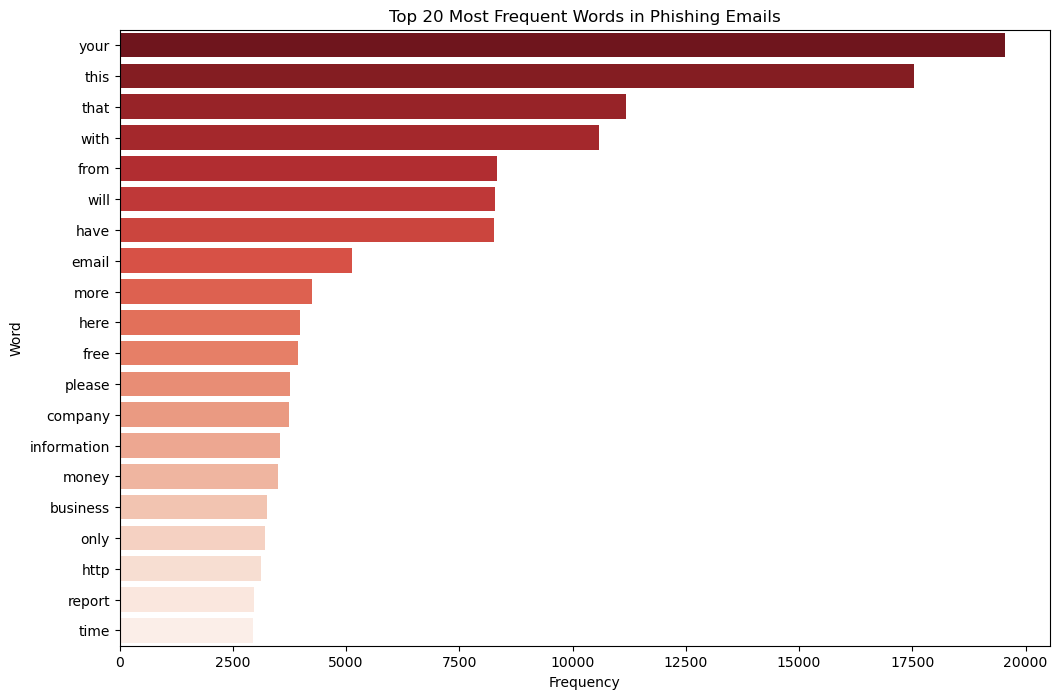

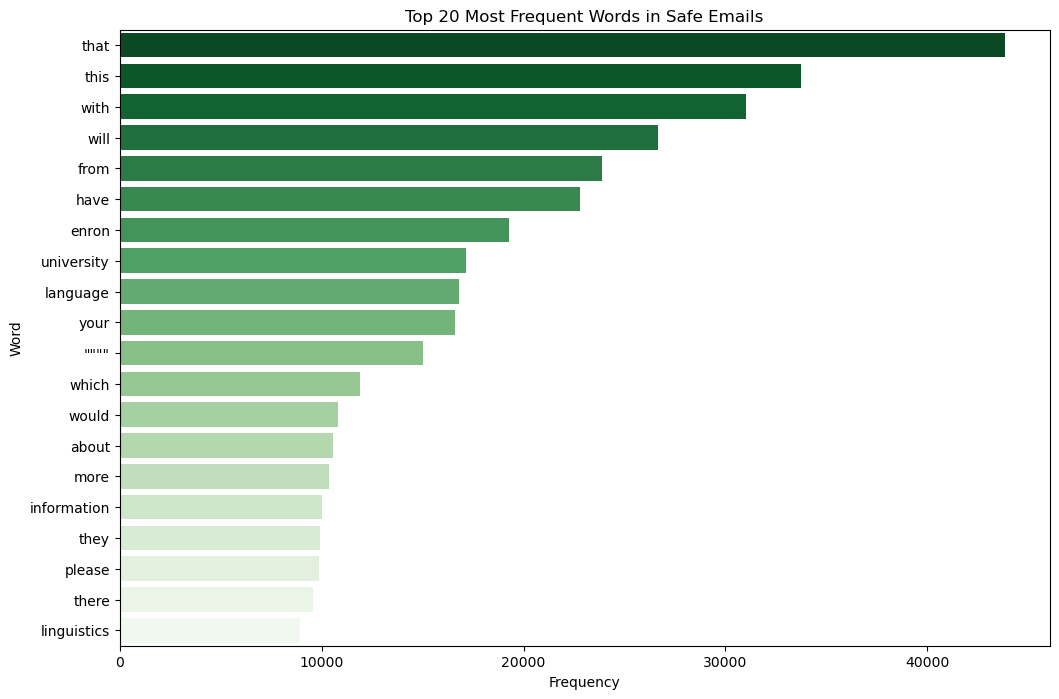

In [33]:
def get_top_n_words(text_series, n=20):
    words = ' '.join(text_series).lower().split()
    words = [word for word in words if len(word) > 3]
    return Counter(words).most_common(n)

top_phishing = get_top_n_words(df[df['label_binary'] == 1]['email_text'])
top_safe = get_top_n_words(df[df['label_binary'] == 0]['email_text'])

df_phishing_words = pd.DataFrame(top_phishing, columns=['Word', 'Frequency'])
df_safe_words = pd.DataFrame(top_safe, columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=df_phishing_words, palette='Reds_r')
plt.title('Top 20 Most Frequent Words in Phishing Emails')
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=df_safe_words, palette='Greens_r')
plt.title('Top 20 Most Frequent Words in Safe Emails')
plt.show()

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'], 
    'solver': ['lbfgs', 'liblinear']
}

lr = LogisticRegression(max_iter=1000, class_weight='balanced')

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)

grid_lr.fit(X_train_tfidf, y_train)

print(f"Best Parameters for Logistic Regression: {grid_lr.best_params_}")
best_lr_model = grid_lr.best_estimator_

Best Parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


In [35]:
from sklearn.metrics import classification_report

y_pred_lr = best_lr_model.predict(X_test_tfidf)
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2265
           1       0.93      0.98      0.96      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.97      0.96      3727
weighted avg       0.97      0.96      0.96      3727



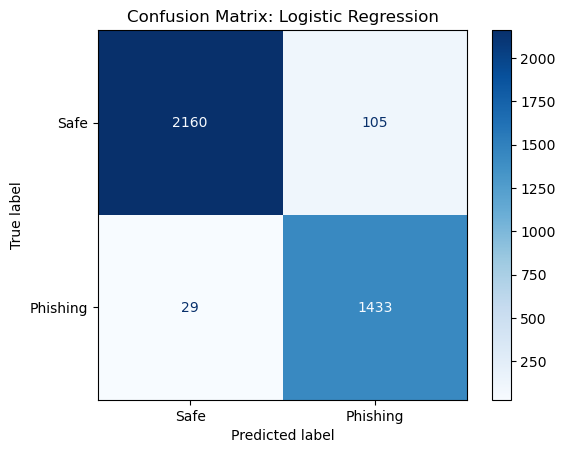

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Safe', 'Phishing'])
disp_lr.plot(cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

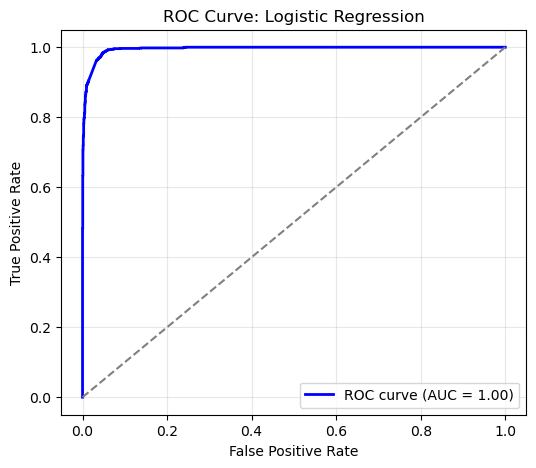

In [37]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = best_lr_model.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

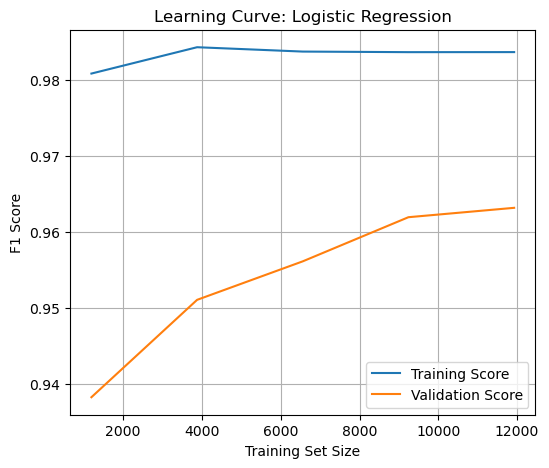

In [38]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_lr_model, X_train_tfidf, y_train, cv=5, scoring='f1', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(6, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve: Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

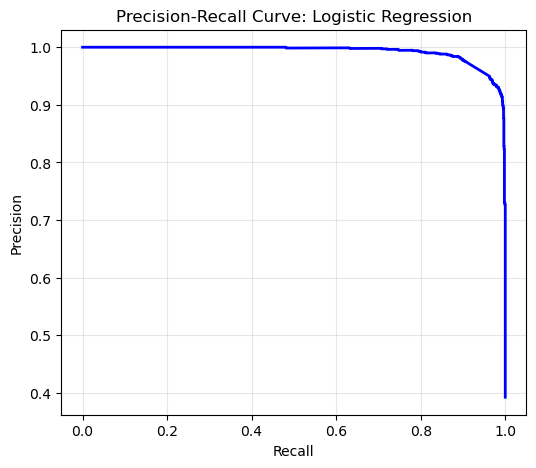

In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Logistic Regression')
plt.grid(alpha=0.3)
plt.show()

In [41]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(best_lr_model, X_train_tfidf, y_train, cv=kf, scoring='accuracy')

print("Logistic Regression K-Fold Scores:", cv_scores_lr)
print(f"Mean Accuracy: {cv_scores_lr.mean():.4f}")
print(f"Standard Deviation: {cv_scores_lr.std():.4f}")

Logistic Regression K-Fold Scores: [0.96344735 0.97015426 0.96779604 0.97282791 0.97115062]
Mean Accuracy: 0.9691
Standard Deviation: 0.0033


In [42]:
import joblib
joblib.dump(best_lr, "logistic_regression_phishing_model.pkl")


['logistic_regression_phishing_model.pkl']